PROBLEM STATEMENT


Analysts are required to explore data and reflect on the insights. Clear writing skill is an integral part of a good report. Note that the explanations must be such that readers with minimum knowledge of analytics is able to grasp the insight. Austo Motor Company is a leading car manufacturer specializing in SUV, Sedan, and Hatchback models. In its recent board meeting, concerns were raised by the members on the efficiency of the marketing campaign currently being used. The board decides to rope in an analytics professional to improve the existing campaign.


1. You as an analyst have been tasked with performing a thorough analysis of the data and coming up with insights to improve the marketing campaign.


A. What is the important technical information about the dataset that a database administrator would be interested in? (Hint: Information about the size of the dataset and the nature of the variables)

B. Take a critical look at the data and do a preliminary analysis of the variables. Do a quality check of the data so that the variables are consistent. Are there any discrepancies present in the data? If yes, perform preliminary treatment of data.

C. Explore all the features of the data separately by using appropriate visualizations and draw insights that can be utilized by the business.

D. Understanding the relationships among the variables in the dataset is crucial for every analytical project. Perform analysis on the data fields to gain deeper insights. Comment on your understanding of the data.

E. Employees working on the existing marketing campaign have made the following remarks. Based on the data and your analysis state whether you agree or disagree with their observations. Justify your answer Based on the data available.
E1) Steve Roger says “Men prefer SUV by a large margin, compared to the women”
E2) Ned Stark believes that a salaried person is more likely to buy a Sedan.
E3) Sheldon Cooper does not believe any of them; he claims that a salaried male is an easier target for a SUV sale over a Sedan Sale.

F. From the given data, comment on the amount spent on purchasing automobiles across the following categories. Comment on how a Business can utilize the results from this exercise. Give justification along with presenting metrics/charts used for arriving at the conclusions. Give justification along with presenting metrics/charts used for arriving at the conclusions.
F1) Gender
F2) Personal_loan

G. From the current data set comment if having a working partner leads to the purchase of a higher-priced car.

H. The main objective of this analysis is to devise an improved marketing strategy to send targeted information to different groups of potential buyers present in the data. For the current analysis use the Gender and Marital_status - fields to arrive at groups with similar purchase history.

In [3]:
import pandas as pd

In [4]:
import seaborn as sns

In [5]:
# data collection
car = pd.read_csv("austo_automobile.csv")

In [6]:
#Data Profiling
print("No. of Records:",car.shape[0])
print("No. of Columns:",car.shape[1])
print("Columns Name:",car.columns)

No. of Records: 1581
No. of Columns: 14
Columns Name: Index(['Age', 'Gender', 'Profession', 'Marital_status', 'Education',
       'No_of_Dependents', 'Personal_loan', 'House_loan', 'Partner_working',
       'Salary', 'Partner_salary', 'Total_salary', 'Price', 'Make'],
      dtype='object')


In [7]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


In [8]:
car.describe()

,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
count,1581.000000,1581.000000,1581.000000,1475.000000,1581.000000,1581.000000
mean,31.922201,2.457938,60392.220114,20225.559322,79625.996205,35597.722960
std,8.425978,0.943483,14674.825044,19573.149277,25545.857768,13633.636545
min,22.000000,0.000000,30000.000000,0.000000,30000.000000,18000.000000
25%,25.000000,2.000000,51900.000000,0.000000,60500.000000,25000.000000
50%,29.000000,2.000000,59500.000000,25600.000000,78000.000000,31000.000000
75%,38.000000,3.000000,71800.000000,38300.000000,95900.000000,47000.000000
max,54.000000,4.000000,99300.000000,80500.000000,171000.000000,70000.000000


In [9]:
car.dtypes

Age                   int64
Gender               object
Profession           object
Marital_status       object
Education            object
No_of_Dependents      int64
Personal_loan        object
House_loan           object
Partner_working      object
Salary                int64
Partner_salary      float64
Total_salary          int64
Price                 int64
Make                 object
dtype: object

In [10]:
# duplicat values
car.duplicated().sum()

np.int64(0)

In [11]:
# check unique values for all columns - it will show the spelling mistakes of categories
car[['Gender', 'Profession', 'Marital_status', 'Education', 'Personal_loan', 'House_loan', 'Partner_working','Make']].apply(lambda x : x.unique())

Gender             [Male, Femal, Female, nan, Femle]
Profession                      [Business, Salaried]
Marital_status                     [Married, Single]
Education                  [Post Graduate, Graduate]
Personal_loan                              [No, Yes]
House_loan                                 [No, Yes]
Partner_working                            [Yes, No]
Make                         [SUV, Sedan, Hatchback]
dtype: object

In [12]:
# correct spelling mistakes --- ("Femal","Femle") with correct word ("Female")
car.Gender = car.Gender.replace(["Femal","Femle"], ["Female","Female"])

In [13]:
# checking after fixing spelling
car.Gender.value_counts()

Gender
Male      1199
Female     329
Name: count, dtype: int64

In [14]:
# missing values
car.isnull().sum()

Age                   0
Gender               53
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64

In [15]:
# replace missing value with Male in Gender, Because of their higher count in Data Set
car.Gender = car.Gender.fillna("Male")

In [16]:
# filling parter salary with help of total_salary and Salary
# formula :- Partner_salary = Total_salary - Salary
car.Partner_salary = car.Total_salary - car.Salary

In [17]:
# confirming is their any other null values
car.isnull().sum()

Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64

# UNIVARITE ANALYSIS

Count in: Gender
Male      1252
Female     329
Name: count, dtype: int64


<Axes: xlabel='Gender'>

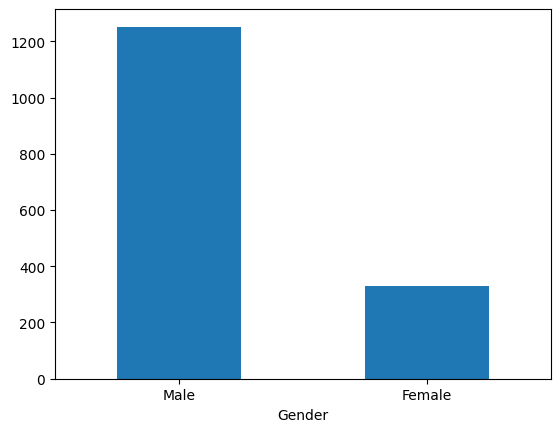

In [18]:
# Gender count
print("Count in:",car.Gender.value_counts())
car.Gender.value_counts().plot.bar(rot=0)

Count in: Profession
Salaried    896
Business    685
Name: count, dtype: int64


<Axes: xlabel='Profession'>

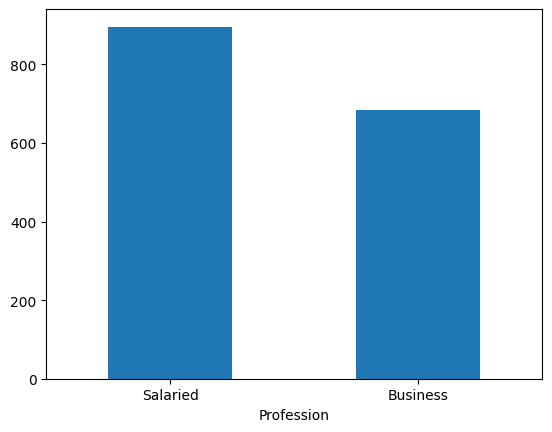

In [19]:
# Profession count
print("Count in:",car.Profession.value_counts())
car.Profession.value_counts().plot.bar(rot=0)

Count in: Marital_status
Married    1443
Single      138
Name: count, dtype: int64


<Axes: xlabel='Marital_status'>

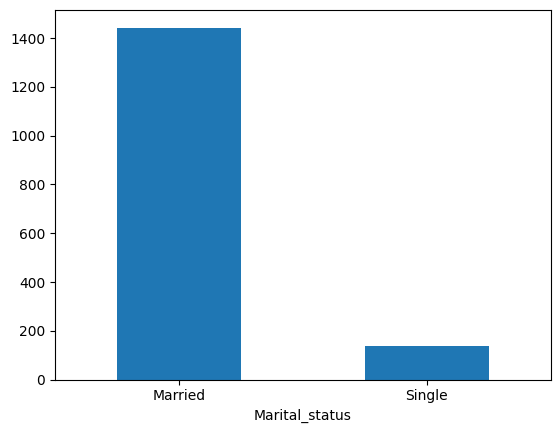

In [20]:
# Marital_status count
print("Count in:",car.Marital_status.value_counts())
car.Marital_status.value_counts().plot.bar(rot=0)

Count in: Education
Post Graduate    985
Graduate         596
Name: count, dtype: int64


<Axes: xlabel='Education'>

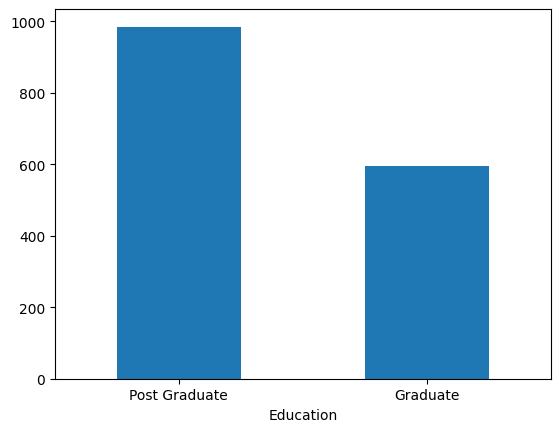

In [21]:
# Education count
print("Count in:",car.Education.value_counts())
car.Education.value_counts().plot.bar(rot=0)

Count in: Personal_loan
Yes    792
No     789
Name: count, dtype: int64


<Axes: xlabel='Personal_loan'>

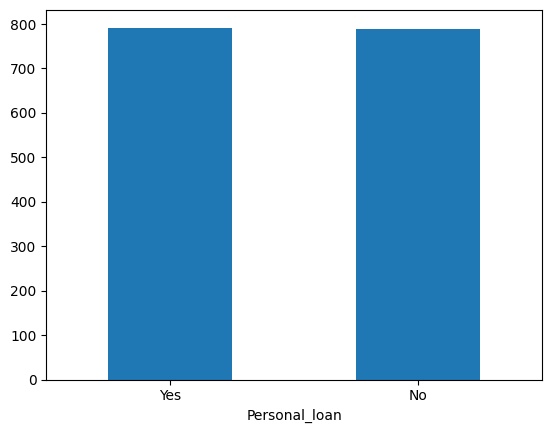

In [22]:
# Personal_loan count
print("Count in:",car.Personal_loan.value_counts())
car.Personal_loan.value_counts().plot.bar(rot=0)

Count in: House_loan
No     1054
Yes     527
Name: count, dtype: int64


<Axes: xlabel='House_loan'>

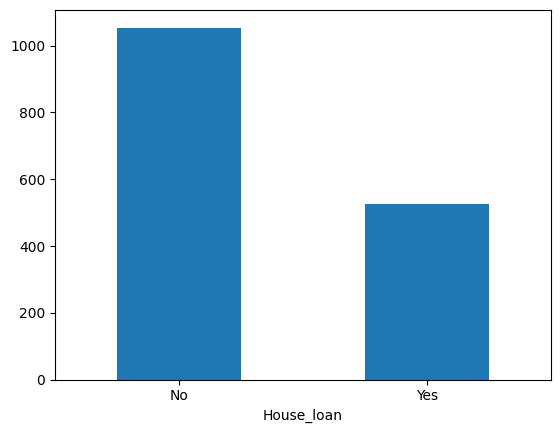

In [23]:
# House_loan count
print("Count in:",car.House_loan.value_counts())
car.House_loan.value_counts().plot.bar(rot=0)

Count in: Partner_working
Yes    868
No     713
Name: count, dtype: int64


<Axes: xlabel='Partner_working'>

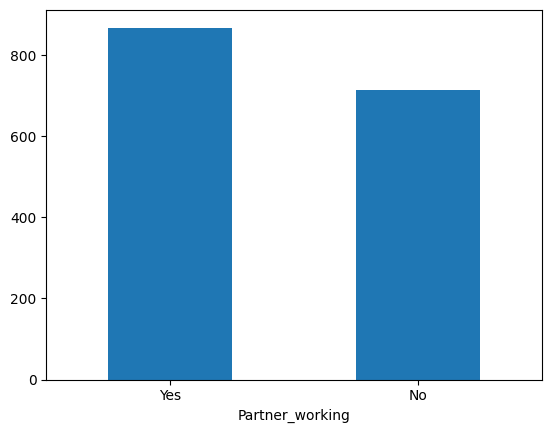

In [24]:
# Partner_working count
print("Count in:",car.Partner_working.value_counts())
car.Partner_working.value_counts().plot.bar(rot=0)

Count in: Make
Sedan        702
Hatchback    582
SUV          297
Name: count, dtype: int64


<Axes: xlabel='Make'>

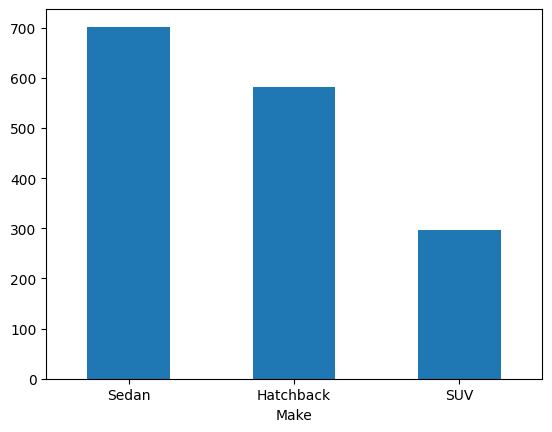

In [25]:
# Make count
print("Count in:",car.Make.value_counts())
car.Make.value_counts().plot.bar(rot=0)

<Axes: xlabel='Age', ylabel='Count'>

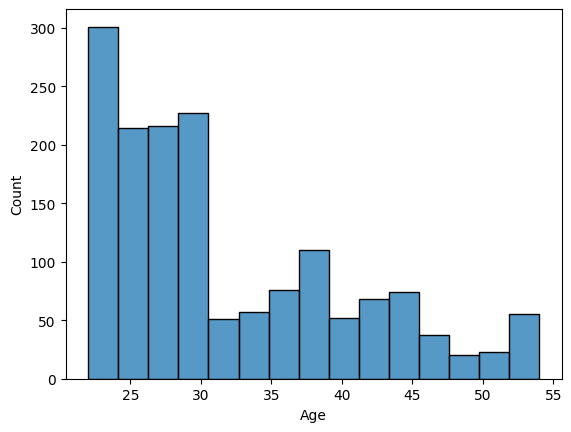

In [26]:
# counting age 
sns.histplot(car.Age)

<Axes: xlabel='No_of_Dependents', ylabel='Count'>

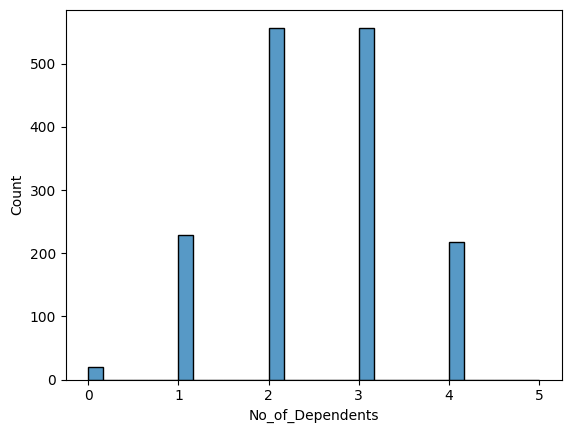

In [27]:
# counting No of Department 
sns.histplot(car.No_of_Dependents, binrange=(0,5))

<Axes: xlabel='Salary', ylabel='Count'>

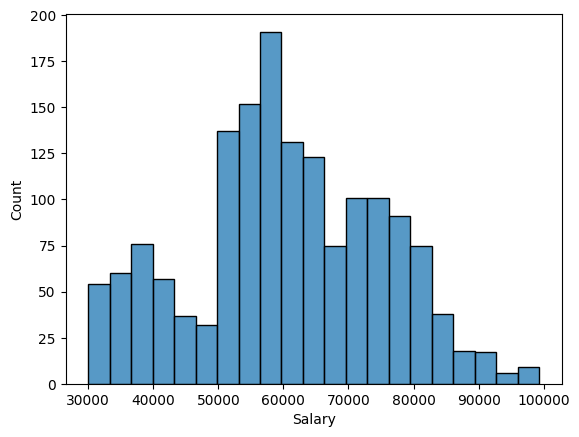

In [28]:
# Salary range
sns.histplot(car.Salary)

<Axes: xlabel='Partner_salary', ylabel='Count'>

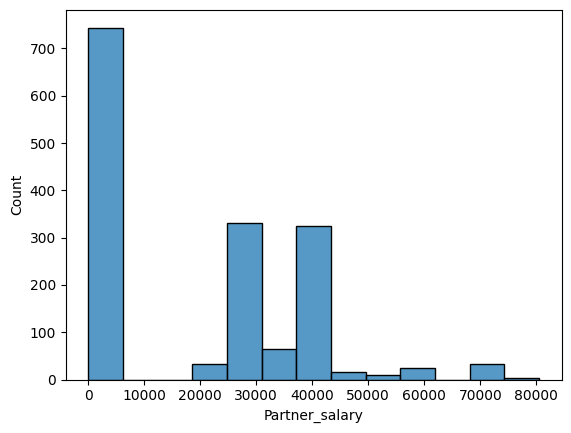

In [29]:
# Partner Salary range
sns.histplot(car.Partner_salary)

<Axes: xlabel='Total_salary', ylabel='Count'>

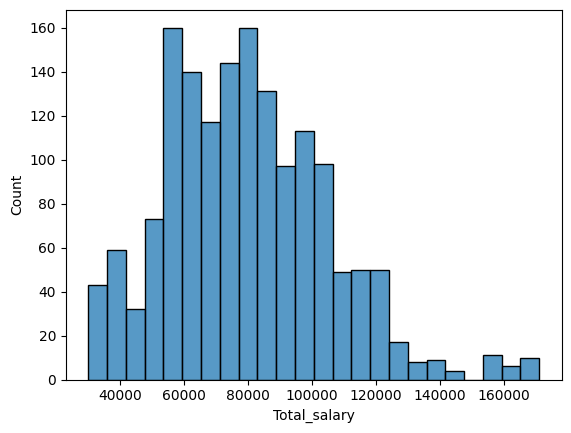

In [30]:
# Total Salary range
sns.histplot(car.Total_salary)

<Axes: xlabel='Price', ylabel='Count'>

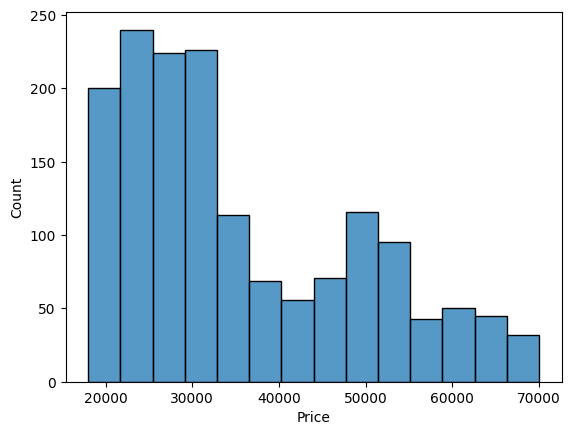

In [31]:
# Price range
sns.histplot(car.Price)

# BIVARIATE ANALYSIS

In [32]:
car.pivot_table(index = "Gender", columns = "Make", aggfunc = "count")["Age"]

Make,Hatchback,SUV,Sedan
Gender,,,
Female,15,173,141
Male,567,124,561


In [33]:
car.groupby(["Gender","Make"])["Make"].count()

Gender  Make     
Female  Hatchback     15
        SUV          173
        Sedan        141
Male    Hatchback    567
        SUV          124
        Sedan        561
Name: Make, dtype: int64

<Axes: xlabel='Gender,Make'>

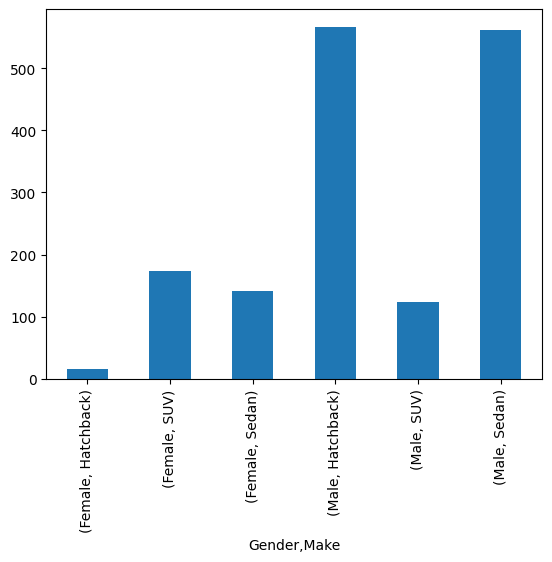

In [34]:
car.groupby(["Gender","Make"])["Make"].count().plot.bar()

# Sampling

In [35]:
# seprating male data from data set
maledata = car[car.Gender == "Male"][["Gender","Make"]]

In [36]:
# creating sample for better analysis (removing biasness)
# Male Sample1
sample1 = maledata.sample(329).groupby("Make").count().rename(columns = {"Gender" : "Male"})

In [37]:
# Male Sample2
sample2 = maledata.sample(329).groupby("Make").count().rename(columns = {"Gender" : "Male"})

In [38]:
# Male Sample3
sample3 = maledata.sample(329).groupby("Make").count().rename(columns = {"Gender" : "Male"})

In [39]:
# seprating female data from data set
femaledata = car[car.Gender == "Female"][["Gender","Make"]]

In [40]:
# female sample
fem = femaledata.groupby("Make").count().rename(columns = {"Gender" : "Female"})

In [41]:
# I am not agree with steve... Females are more interested in SUV over Male

<Axes: xlabel='Make'>

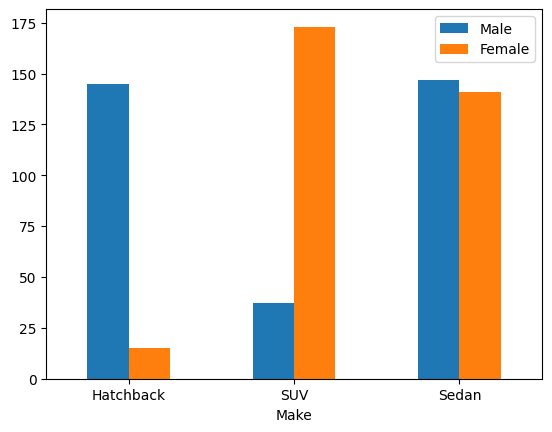

In [42]:
# visualising result with sample1
pd.concat([sample1,fem], axis = 1).plot.bar(rot = 0)

<Axes: xlabel='Make'>

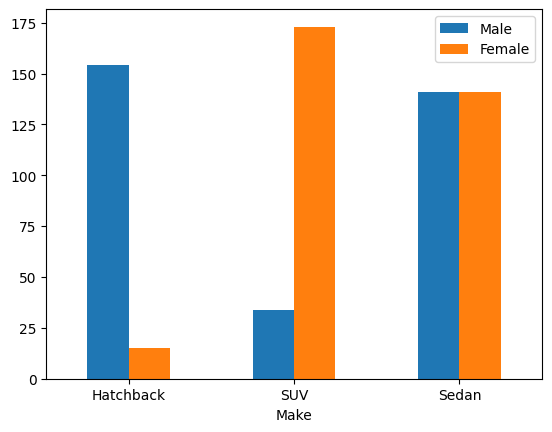

In [43]:
# visualising result with sample2
pd.concat([sample2,fem], axis = 1).plot.bar(rot = 0)

<Axes: xlabel='Make'>

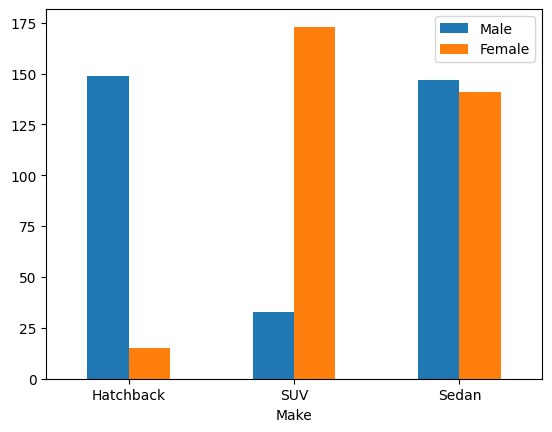

In [44]:
# visualising result with sample3
pd.concat([sample3,fem], axis = 1).plot.bar(rot = 0)

In [45]:
# taking Male - SUV data from all samples  
sample1.iloc[1][0]
sample2.iloc[1][0]
sample3.iloc[1][0]

C:\Users\Mehul\AppData\Local\Temp\ipykernel_13220\125689699.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample1.iloc[1][0]
C:\Users\Mehul\AppData\Local\Temp\ipykernel_13220\125689699.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample2.iloc[1][0]
C:\Users\Mehul\AppData\Local\Temp\ipykernel_13220\125689699.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample3.iloc[1][0]


np.int64(33)

In [46]:
# converting and storing all suv data into list for comparision
suvm = [sample1.iloc[1][0], sample2.iloc[1][0], sample3.iloc[1][0]]
suvf = [ 173, 173, 173]

C:\Users\Mehul\AppData\Local\Temp\ipykernel_13220\167609515.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  suvm = [sample1.iloc[1][0], sample2.iloc[1][0], sample3.iloc[1][0]]


<Axes: >

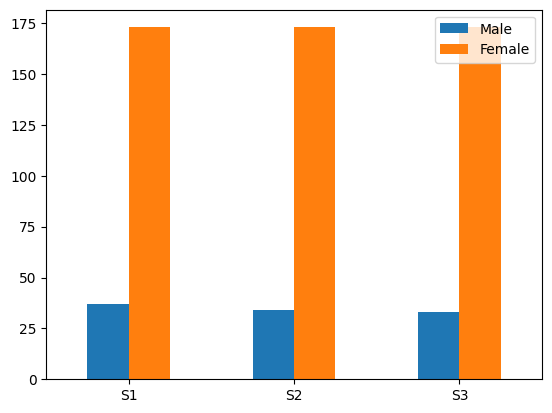

In [47]:
# comprision between Male and Female fro SUV
pd.DataFrame({"Male":suvm, "Female": suvf}, index= ["S1", "S2", "S3"]).plot.bar(rot= 0)

Make        Hatchback  SUV  Sedan
Profession                       
Business          290   89    306
Salaried          292  208    396


<Axes: xlabel='Profession'>

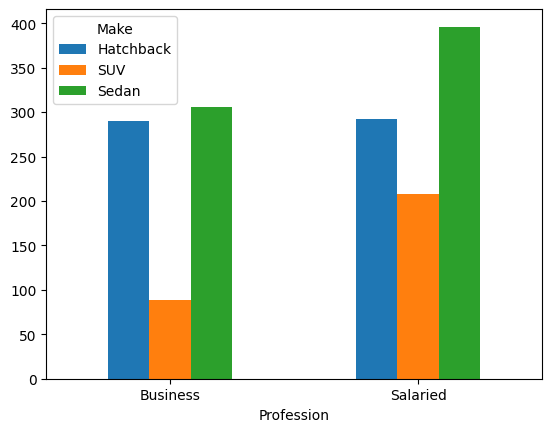

In [48]:
# comparision between Profession and Make
print(pd.crosstab(car["Profession"], car["Make"]))
pd.crosstab(car["Profession"], car["Make"]).plot.bar(rot = 0)

Make            Hatchback  SUV  Sedan
Marital_status                       
Married               498  281    664
Single                 84   16     38


<Axes: xlabel='Marital_status'>

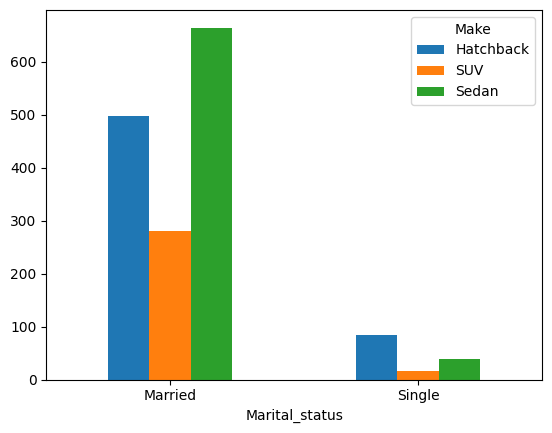

In [49]:
# comparision between Marital Status and Make
print(pd.crosstab(car["Marital_status"], car["Make"]))
pd.crosstab(car["Marital_status"], car["Make"]).plot.bar(rot = 0)

Make           Hatchback  SUV  Sedan
Education                           
Graduate             220  117    259
Post Graduate        362  180    443


<Axes: xlabel='Education'>

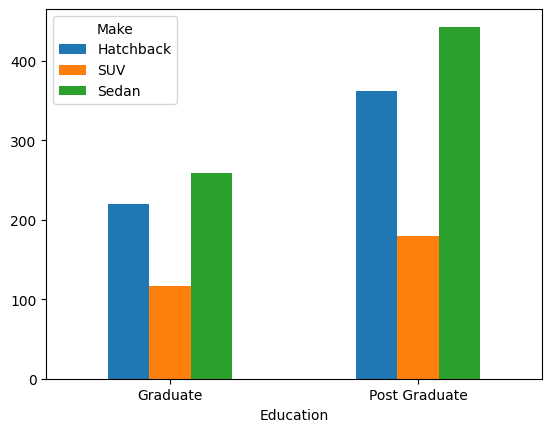

In [50]:
# comparision between Education and Make
print(pd.crosstab(car["Education"], car["Make"]))
pd.crosstab(car["Education"], car["Make"]).plot.bar(rot = 0)

Make           Hatchback  SUV  Sedan
Personal_loan                       
No                   291  181    317
Yes                  291  116    385


<Axes: xlabel='Personal_loan'>

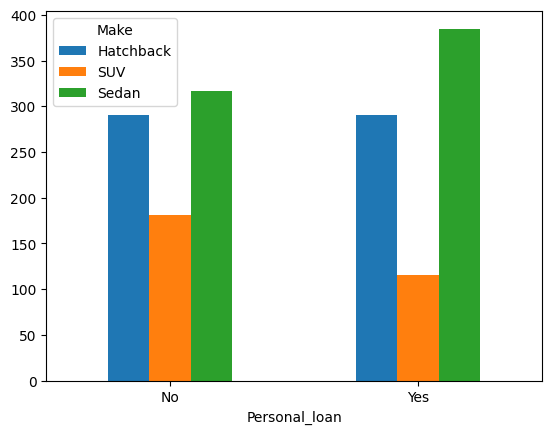

In [51]:
# comparision between Personal Loan and Make
print(pd.crosstab(car["Personal_loan"], car["Make"]))
pd.crosstab(car["Personal_loan"], car["Make"]).plot.bar(rot = 0)

Make        Hatchback  SUV  Sedan
House_loan                       
No                347  275    432
Yes               235   22    270


<Axes: xlabel='House_loan'>

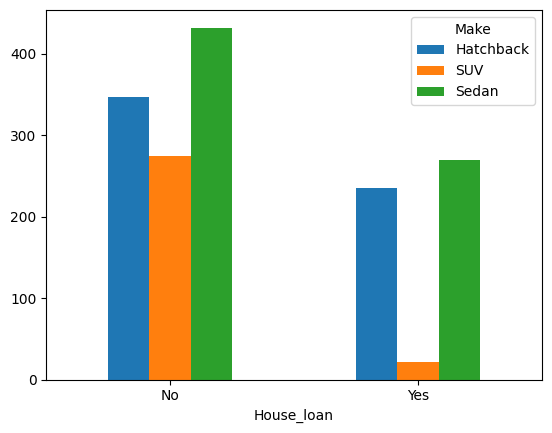

In [52]:
# comparision between House Loan and Make
print(pd.crosstab(car["House_loan"], car["Make"]))
pd.crosstab(car["House_loan"], car["Make"]).plot.bar(rot = 0)

Make             Hatchback  SUV  Sedan
Partner_working                       
No                     281  144    288
Yes                    301  153    414


<Axes: xlabel='Partner_working'>

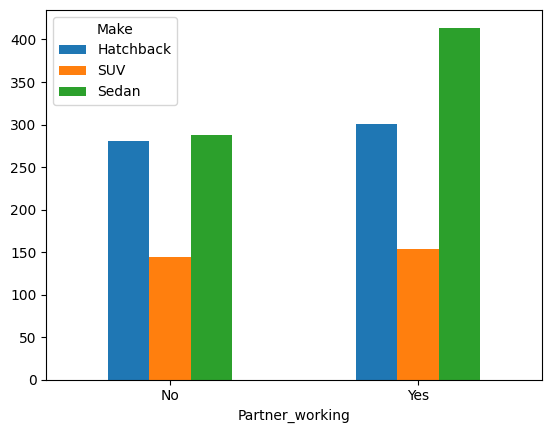

In [53]:
# comparision between Partner working and Make
print(pd.crosstab(car["Partner_working"], car["Make"]))
pd.crosstab(car["Partner_working"], car["Make"]).plot.bar(rot = 0)

<Axes: xlabel='Make', ylabel='Salary'>

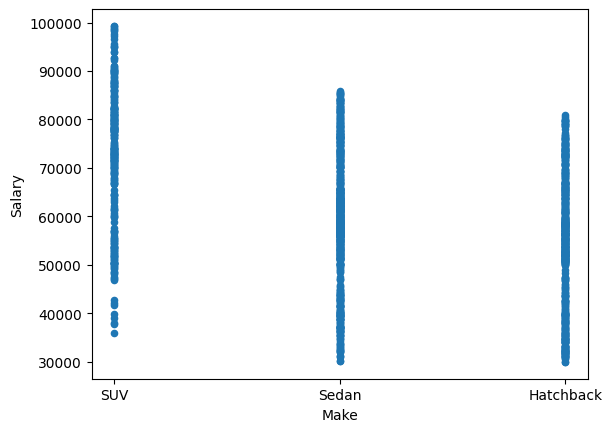

In [54]:
# comparision between salary and Make
car.plot.scatter(x="Make", y="Salary")

<Axes: xlabel='Make', ylabel='Partner_salary'>

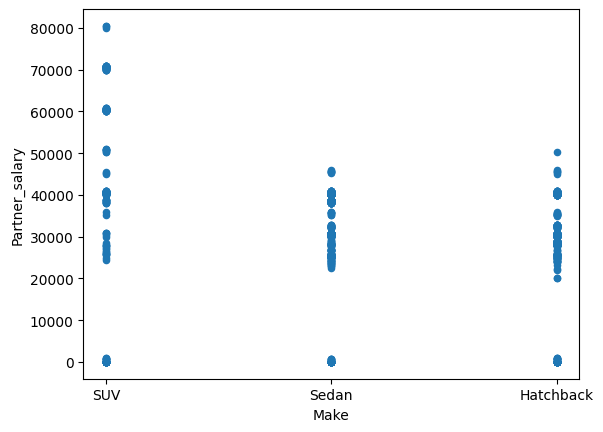

In [55]:
# comparision between partner salary and Make
car.plot.scatter(x="Make", y="Partner_salary")

<Axes: xlabel='Make', ylabel='Partner_salary'>

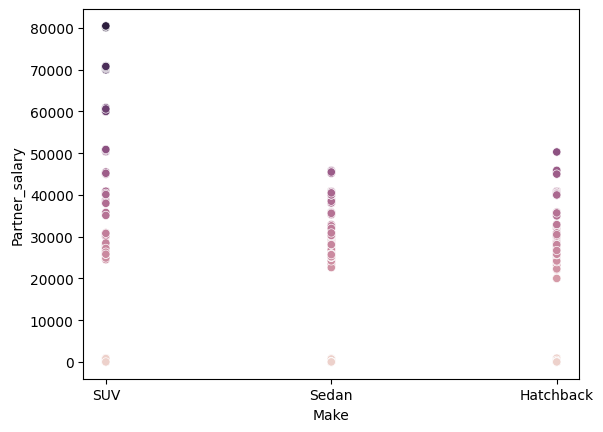

In [56]:
sns.scatterplot(data= car,x="Make", y="Partner_salary", hue= "Partner_salary", legend=False)

Make              Hatchback  SUV  Sedan
No_of_Dependents                       
0                        15    5      0
1                        11   34    184
2                       181   87    289
3                       256  117    184
4                       119   54     45


<Axes: xlabel='No_of_Dependents'>

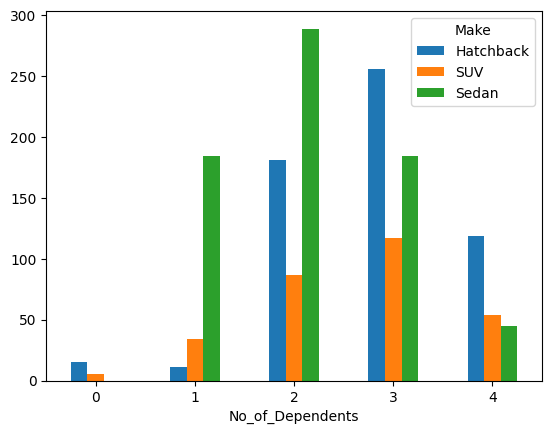

In [57]:
# comparision between   
print(pd.crosstab(car["No_of_Dependents"], car["Make"]))
pd.crosstab(car["No_of_Dependents"], car["Make"]).plot.bar(rot = 0)

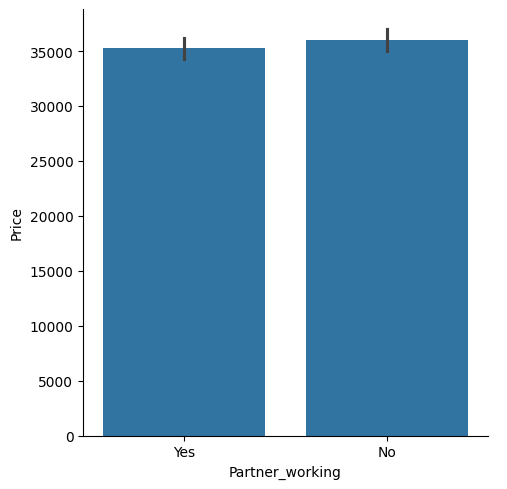

In [58]:
sns.catplot(data= car, x= "Partner_working", y= "Price", kind= "bar")

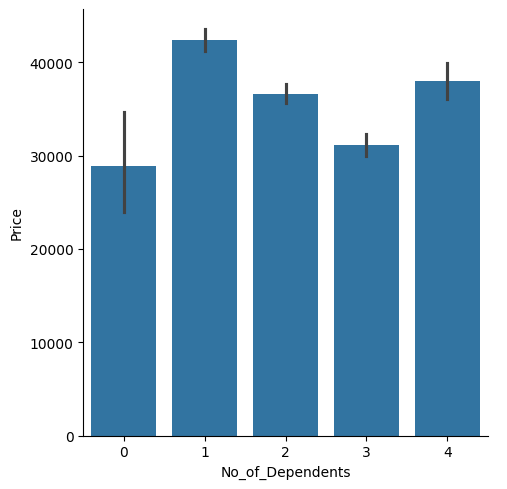

In [59]:
sns.catplot(data= car, x= "No_of_Dependents", y= "Price", kind= "bar")

<Axes: xlabel='Profession,Make'>

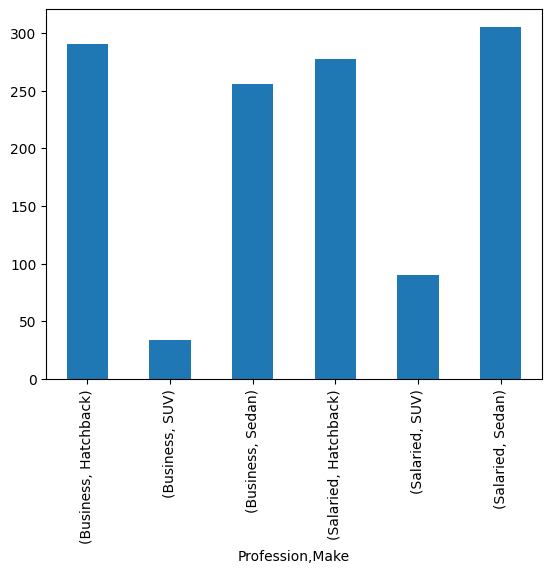

In [60]:
# comparision for Male, Profession and Make
car[car["Gender"] == "Male"].groupby(["Profession", "Make"])["Make"].count()
car[car["Gender"] == "Male"].groupby(["Profession", "Make"])["Make"].count().plot.bar()

<Axes: xlabel='Gender,Profession,Make'>

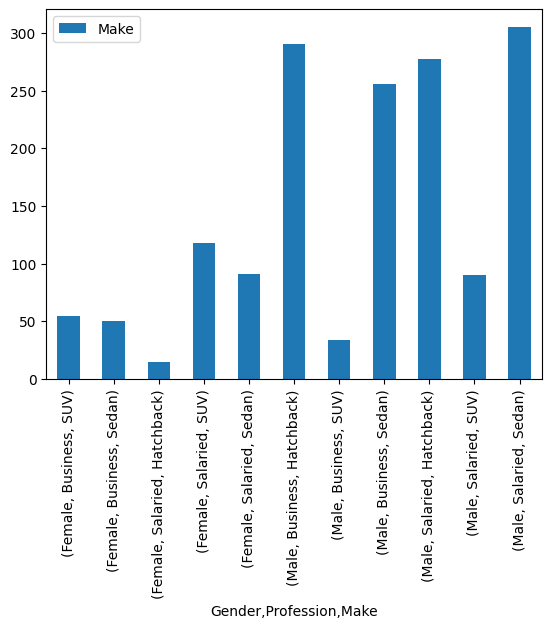

In [61]:
# comparision between 3 Variables
pd.DataFrame(car.groupby(["Gender","Profession","Make"])["Make"].count())
pd.DataFrame(car.groupby(["Gender","Profession","Make"])["Make"].count()).plot.bar()

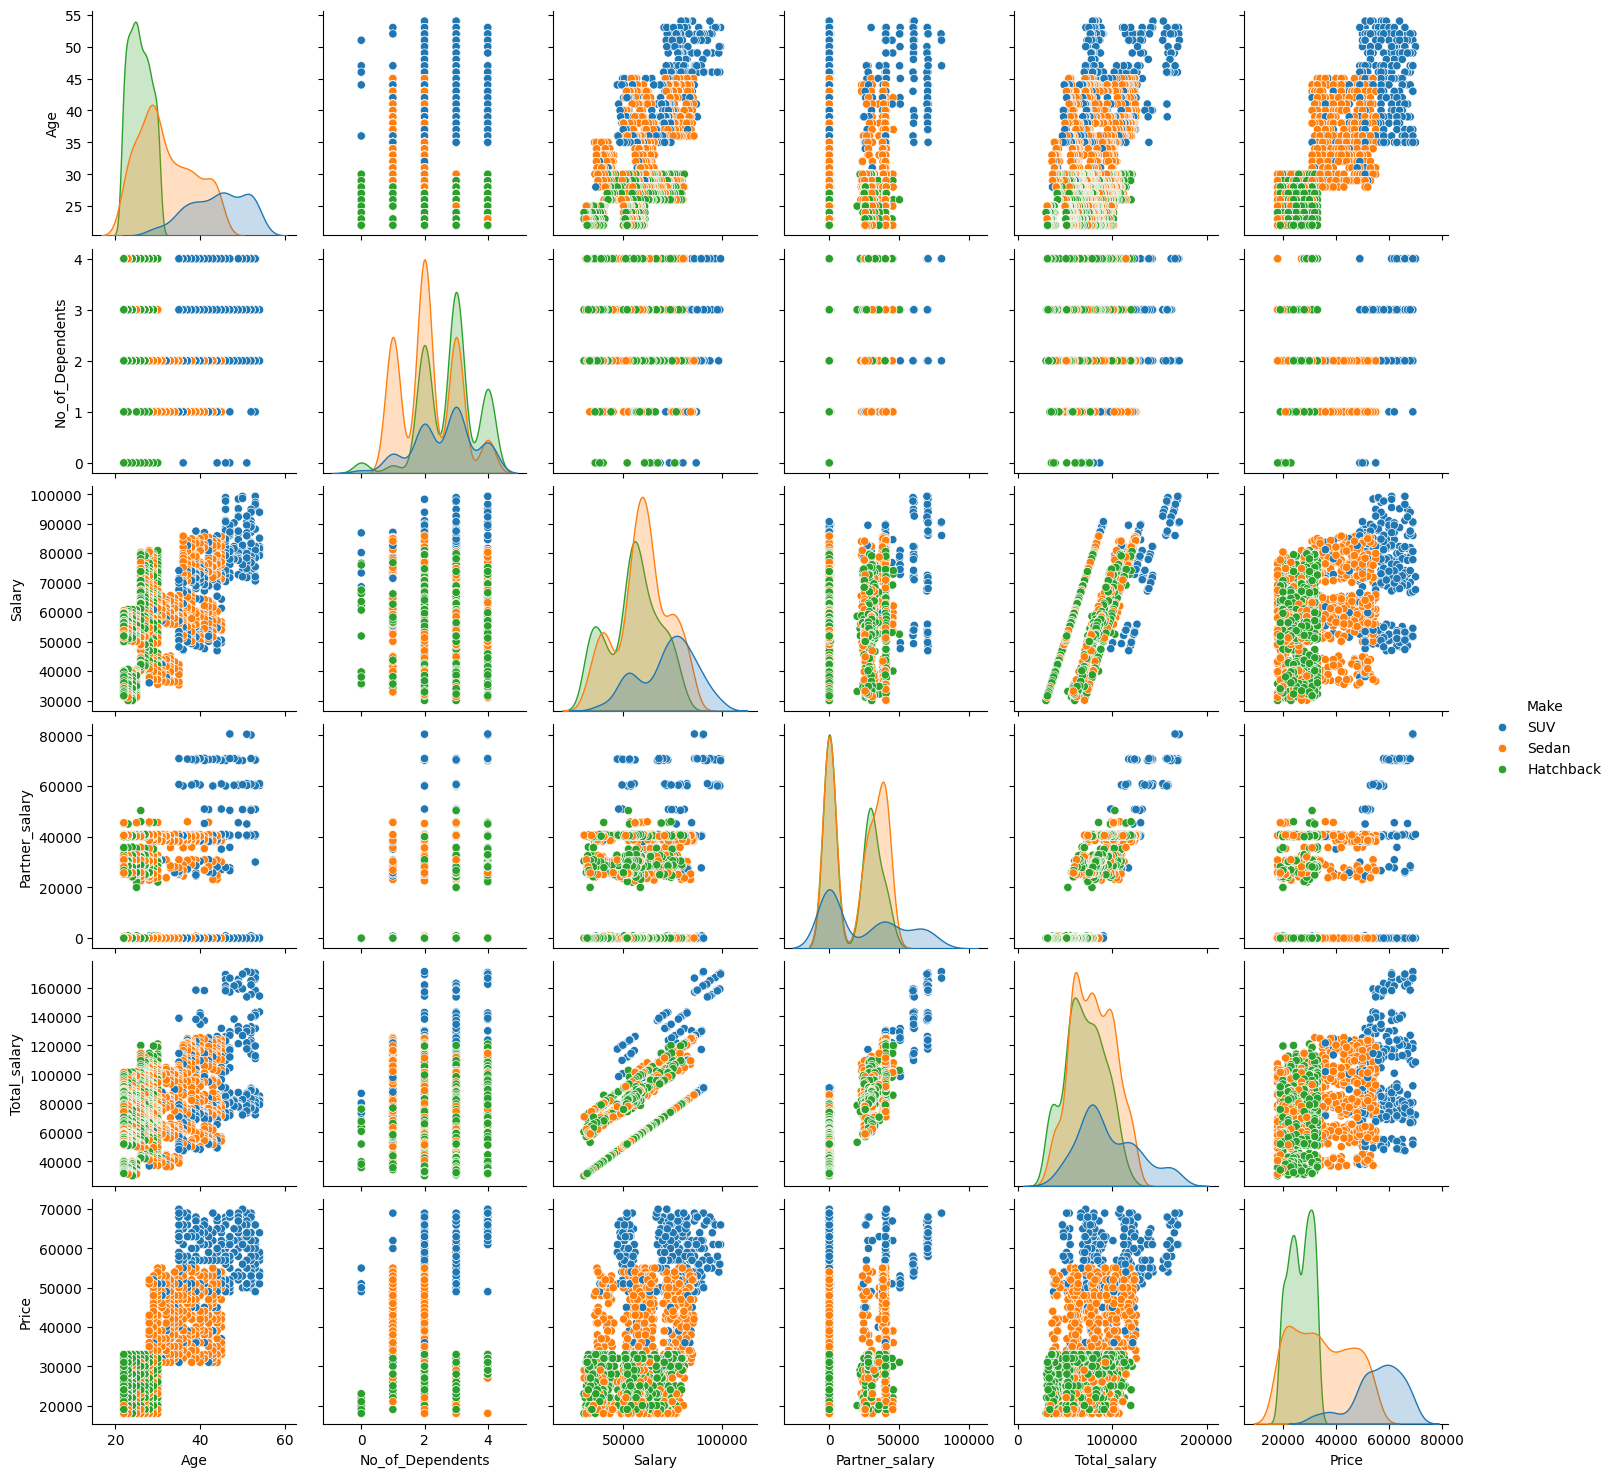

In [62]:
sns.pairplot(car, hue= "Make")

<Axes: xlabel='Gender'>

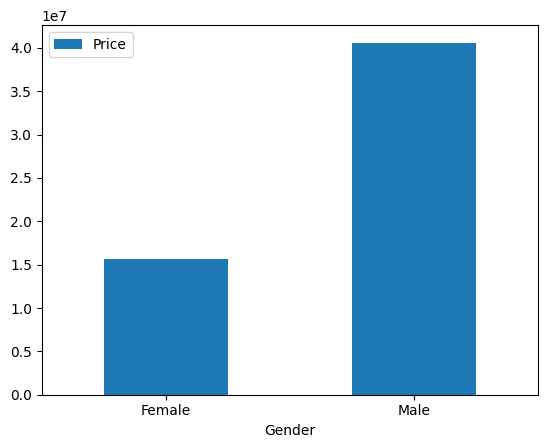

In [63]:
car.pivot_table(index = "Gender", values="Price",aggfunc = "sum").plot.bar(rot=0)

In [64]:
# total spend on car by Gender 
car.pivot_table(index = "Gender", columns = "Make", values="Price",aggfunc = "sum")

Make,Hatchback,SUV,Sedan
Gender,,,
Female,412000,9252000,6031000
Male,14996000,7328000,18261000


                  Price
Personal_loan          
No             28990000
Yes            27290000


<Axes: xlabel='Personal_loan'>

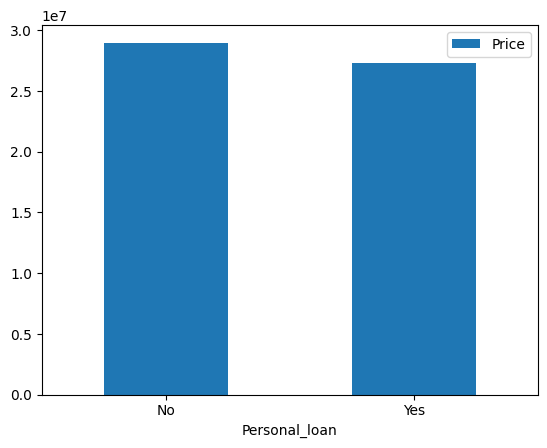

In [65]:
print(car.pivot_table(index = "Personal_loan", values="Price", aggfunc = "sum"))
car.pivot_table(index = "Personal_loan", values="Price", aggfunc = "sum").plot.bar(rot=0)

In [66]:
# total spend on car while considering Personal loan 
car.pivot_table(index = "Personal_loan", columns = "Make", values="Price",aggfunc = "sum")

Make,Hatchback,SUV,Sedan
Personal_loan,,,
No,7765000,10373000,10852000
Yes,7643000,6207000,13440000


<Axes: xlabel='Partner_working'>

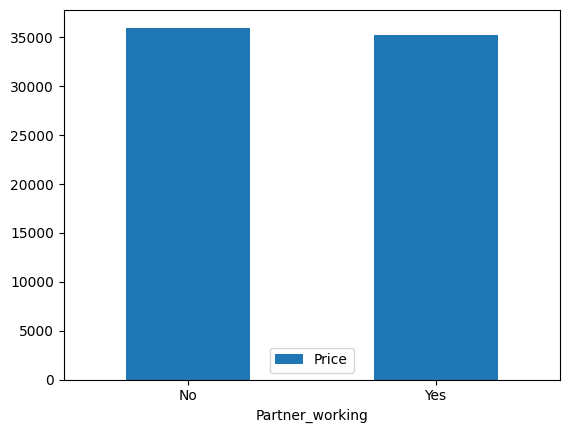

In [67]:
# does partner working affect the car purchase
car.pivot_table(index = "Partner_working", values="Price", aggfunc = "mean").round(2).plot.bar(rot=0)

<Axes: xlabel='Partner_working'>

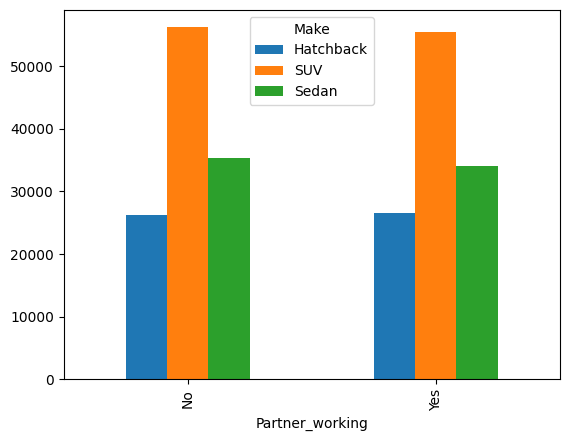

In [68]:
# does partner working affect the car purchase
car.pivot_table(index = "Partner_working", columns = "Make", values="Price", aggfunc = "mean").round(2).plot.bar()

In [69]:
car.pivot_table(index = "Marital_status", columns = ["Make","Gender"], aggfunc = "count")["Age"]

Make           Hatchback         SUV       Sedan     
Gender            Female Male Female Male Female Male
Marital_status                                       
Married               14  484    166  115    127  537
Single                 1   83      7    9     14   24

In [70]:
Married_male = car.loc[(car["Gender"] == "Male") & (car["Marital_status"] == "Married")]
Married_female = car.loc[(car["Gender"] == "Female") & (car["Marital_status"] == "Married")]

single_Male = car.loc[(car["Gender"] == "Male") & (car["Marital_status"] == "Single")]
single_female = car.loc[(car["Gender"] == "Female") & (car["Marital_status"] == "Single")]


<Axes: ylabel='Married_male'>

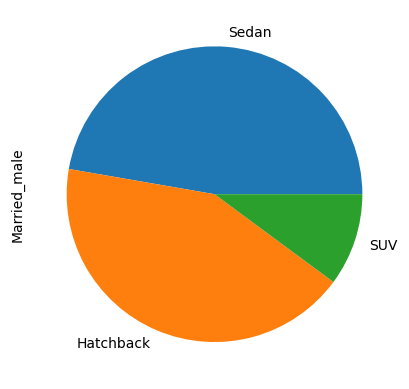

In [71]:
pie1 = Married_male["Make"].value_counts()
# Call the method directly on your variable 'pie1'
pie1.plot.pie(y="Make",  ylabel = "Married_male",legend=False)

<Axes: ylabel='Married_female'>

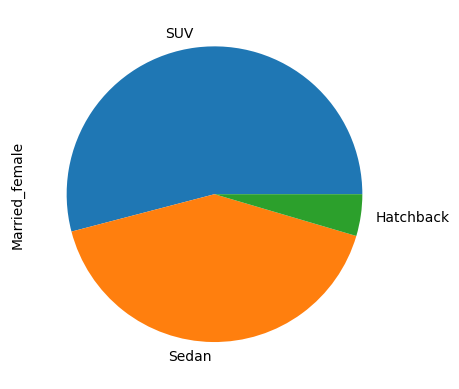

In [72]:
pie2 = Married_female["Make"].value_counts()
# Call the method directly on your variable 'pie1'
pie2.plot.pie(y="Make",  ylabel = "Married_female",legend=False)

<Axes: ylabel='single_Male'>

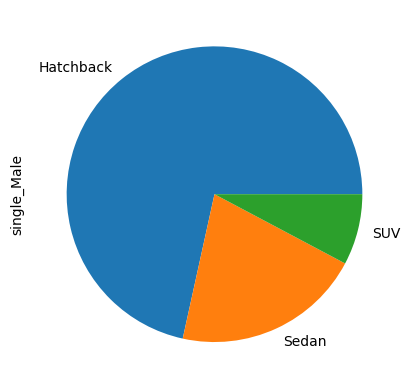

In [73]:
pie3 = single_Male["Make"].value_counts()
# Call the method directly on your variable 'pie1'
pie3.plot.pie(y="Make",  ylabel = "single_Male",legend=False)

<Axes: ylabel='single_female'>

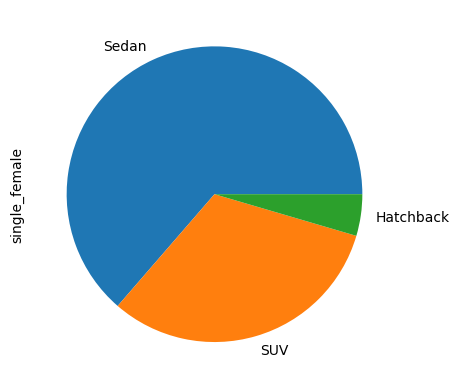

In [74]:
pie4 = single_female["Make"].value_counts()
# Call the method directly on your variable 'pie1'
pie4.plot.pie(y="Make",  ylabel = "single_female",legend=False)